In [1]:
def get_top_keywords(url: str, k: int = 10, return_details: bool = False):
    import re
    import urllib.request
    from urllib.parse import urlparse
    from collections import Counter, defaultdict
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    import nltk
    import requests
    import math

    # --------------------- ensure NLTK data ---------------------
    try:
        stopwords.words("finnish")
    except LookupError:
        nltk.download("stopwords")
    try:
        stopwords.words("english")
    except LookupError:
        nltk.download("stopwords")

    # --------------------- ensure Finnish stemmer ---------------------
    try:
        from nltk.stem.snowball import SnowballStemmer
    except ImportError:
        nltk.download('snowball_data')
        from nltk.stem.snowball import SnowballStemmer

    # --------------------- ensure langdetect is installed ---------------------
    try:
        from langdetect import detect
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "langdetect"])
        from langdetect import detect

    # --------------------- ensure yake is installed ---------------------
    try:
        import yake
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "yake"])
        import yake

    # --------------------- config ---------------------
    COMMON_NOISE_WORDS = set("""
    January debt est dec big than who use jun jan feb mar apr may jul august dec oct nov sep dec
    product continue one two three four five please thanks find helpful week job experience women girl
    apology read show eve knowledge benefit appointment street way staff salon discount gift cost thing
    world close party love letters rewards offers special close pack wed dollars voucher gifts vouchers
    welcome therefore march nights need name please show sisters thank menu today always time needs
    welcome march february april may june jully august september october november december day year
    month minute second seconds
    """.split())
    my_noise_words_ruoka = set(
    )
    my_noise_words_india_2nd_set = set(
        {
            "valkokaal",
            "riisinkeittim",
            "rkl",
            "chil",
            "nauta",
            "marokkolais",
            "hetk",
            "viipal",
            "seko",
            "viagr",
            "kup",
            "suosik",
            "juoksev",
            "punain",
            "tapaks",
            "viera",
            "karamelliomeno",
            "raastetu",
            "menu",
            "riis",
            "nimi",
            "suikaloi",
            "hapattim",
            "sitruunak",
            "kunnes",
            "sipul",
            "silputu",
            "kuoritu",
            "uun",
            "vaalea",
            "ruokaöljy",
            "balsamicokastik",
            "chorizojauhelihapihv",
            "maustein",
            "muna",
            "linssikasviscury",
            "levä",
            "focaccialei",
            "kuskus",
            "keitinpiir",
            "grillileik",
            "lämpö",
            "käyttäm",
            "maito",
            "graavisiik",
            "kauraleip",
            "simo",
            "keittim",
            "aasialaisit",
            "korm",
            "murskatu",
            "kanafond",
            "taikin",
            "jäätelökonekes",
            "teko",
            "täytety",
            "kermaseos",
            "lämmittäv",
            "kasvist",
            "leik",
            "olkiperuno",
            "lautas",
            "valm",
            "huuhdo",
            "chorizolammaspyöryk",
            "ruisjauho",
            "jäädäks",
            "punasipul",
            "päät",
            "tapa",
            "korvasienikastik",
            "puolukkashot",
            "resept",
            "yojuhl",
            "kalaparsapiirak",
            "nos",
            "broilerinleik",
            "katkarapuparsapiiras",
            "taina",
            "appelsiin",
            "lap",
            "hienon",
            "crme",
            "sitruun",
            "pin",
            "paahtaj",
            "kera",
            "seos",
            "reikälei",
            "valmistetu",
            "vatk",
            "tasais",
            "seesaminsiemen",
            "tuli",
            "muscovado",
            "pippur",
            "kuumen",
            "täyte",
            "timjam",
            "brut",
            "tee",
            "komment",
            "kaada",
            "majonees",
            "kastik",
            "malesialain",
            "taik",
            "kaalikurpitsapiirak",
            "kypsen",
            "wasab",
            "rasv",
            "suikaloitu",
            "sienipiirak",
            "voita",
            "lihapullacury",
            "kaal",
            "pastakastik",
            "italialais",
            "höyrytety",
            "peking",
            "koko",
            "hunaj",
            "puoluko",
            "liina",
            "kesäkurpits",
            "hurm",
            "pais",
            "dan",
            "vars",
            "kyse",
            "kinkkujuustopiiras",
            "savupaprikajauh",
            "dick",
            "lehtikaalijuustopiirak",
            "raikas",
            "paksoi",
            "mieto",
            "leipomin",
            "lihasienipiirak",
            "valu",
            "suola",
            "sitruunamehu",
            "obh",
            "oregano",
            "bulgurkasvispae",
            "nino",
            "kookoslimettinuget",
            "lehtikaalijuustopiiras",
            "purjosipul",
            "codornu",
            "salovaar",
            "viikonlopu",
            "expres",
            "kahd",
            "valkosipul",
            "lohicarpacio",
            "haukirapumurek",
            "lihamakaronilaatiko",
            "past",
            "vink",
            "kiehuv",
            "maus",
            "hirvikaud",
            "ohj",
            "keitety",
            "bangkok",
            "file",
            "tehd",
            "paistijauhelih",
            "täyteläin",
            "raaka",
            "bengal",
            "sienipinaattipiirak",
            "kampasimpuko",
            "tervetulo",
            "minuut",
            "marinad",
            "koho",
            "saa",
            "pohj",
            "korianter",
            "ohu",
            "hallikaupia",
            "oliiviöljy",
            "punaviin",
            "kokonaispist",
            "jättilihapul",
            "inkiväärilimebrl",
            "kuori",
            "liha",
            "make",
            "kookoskaneliriisipuuro",
            "pikalei",
            "savusuol",
            "väri",
            "vast",
            "savuin",
            "kunia",
            "pada",
            "tabboulehsalaat",
            "sitruunanmehu",
            "limemarinoidu",
            "horitikimaalaissalaat",
            "kylm",
            "dijo",
            "kyps",
            "nap",
            "ruokaf",
            "lihavok",
            "ravents",
            "koto",
            "hienonnetu",
            "porkkan",
            "broilerikaalikeito",
            "ohue",
            "voitaik",
            "alkoholittom",
            "hurmaav",
            "lieme",
            "sobanuudelisalaat",
            "kevätsipul",
            "ostosl",
            "silpu",
            "tuoksu",
            "valmist",
            "kurku",
            "kinkkuperunamunakas",
            "lindertz",
            "heinäkasaperun",
            "panu",
            "sormisuol",
            "mehu",
            "leivo",
            "mustapippur",
            "chorizomakkar",
            "herkul",
            "vuoka",
            "levy",
            "japanilaistyylin",
            "lisä",
            "pois",
            "lihacury",
            "karitsanpotk",
            "kof",
            "maukas",
            "hunajapunav",
            "marinoidu",
            "sukker",
            "sitruunaruoho",
            "keskitaso",
            "mausteöljy",
            "pommac",
            "maustetu",
            "nyyti",
            "sekavihannesspaget",
            "italial",
            "munacury",
            "kone",
            "uunipanu",
        }
    )

    # Finnish-specific noise words (site navigation, UI elements, etc.)
    finnish_noise_words = set("""
    blogit kommentit kommentoi peruuta avainsanat tunnisteet valmistusohje ainekset menu
    ruokalista viikon helpot herkulliset arkiruoat juhlamenu mukana maku pippurimylly
    yrttiopas myös sivusto sivu kuvat kuva video videot linkit linkki etusivu hae haku
    rekisteri rekisteröidy kirjaudu ulos sisään uutiset uutinen artikkelit artikkeli
    resept komment keskustelu vink tervetulo ohj make teko tehd nap keit kone
    sähköpostiosoit kulho keittim kokonaispist iso tila
    """.split())

    # Mapping from langdetect language codes to NLTK stopwords language names
    LANG_CODE_TO_NLTK = {
        'af': 'afrikaans',
        'ar': 'arabic',
        'bg': 'bulgarian',
        'bn': 'bengali',
        'ca': 'catalan',
        'cs': 'czech',
        'cy': 'welsh',
        'da': 'danish',
        'de': 'german',
        'el': 'greek',
        'en': 'english',
        'es': 'spanish',
        'et': 'estonian',
        'fa': 'persian',
        'fi': 'finnish',
        'fr': 'french',
        'gu': 'gujarati',
        'he': 'hebrew',
        'hi': 'hindi',
        'hu': 'hungarian',
        'id': 'indonesian',
        'it': 'italian',
        'ja': 'japanese',
        'kn': 'kannada',
        'ko': 'korean',
        'lt': 'lithuanian',
        'lv': 'latvian',
        'mk': 'macedonian',
        'ml': 'malayalam',
        'mr': 'marathi',
        'ne': 'nepali',
        'nl': 'dutch',
        'no': 'norwegian',
        'pa': 'punjabi',
        'pl': 'polish',
        'pt': 'portuguese',
        'ro': 'romanian',
        'ru': 'russian',
        'sk': 'slovak',
        'sl': 'slovenian',
        'so': 'somali',
        'sq': 'squarish',
        'sv': 'swedish',
        'ta': 'tamil',
        'te': 'telugu',
        'th': 'thai',
        'tl': 'tagalog',
        'tr': 'turkish',
        'uk': 'ukrainian',
        'vi': 'vietnamese',
        'zh-cn': 'chinese_simplified',
        'zh-tw': 'chinese_traditional',
    }

    # --------------------- helpers ---------------------
    def _extract_meta_keywords(soup, detected_lang='finnish'):
        """Extract keywords from meta tags and structured data"""
        keywords = []

        # Extract from meta keywords tag
        meta_keywords = soup.find('meta', attrs={'name': 'keywords'})
        if meta_keywords and meta_keywords.get('content'):
            content = meta_keywords.get('content', '')
            for kw in content.split(','):
                kw = kw.strip().lower()
                if kw:
                    normalized = _normalize_finnish_word(kw, detected_lang)
                    keywords.append(normalized)

        # Extract from meta description
        meta_desc = soup.find('meta', attrs={'name': 'description'})
        if meta_desc and meta_desc.get('content'):
            desc = meta_desc.get('content', '').lower()
            # Extract words from description
            for word in desc.split():
                word = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', word)
                if len(word) > 2:
                    normalized = _normalize_finnish_word(word, detected_lang)
                    keywords.append(normalized)

        # Extract from Open Graph tags
        og_tags = ['og:title', 'og:description', 'og:site_name']
        for og_tag in og_tags:
            og_meta = soup.find('meta', property=og_tag)
            if og_meta and og_meta.get('content'):
                content = og_meta.get('content', '').lower()
                for word in content.split():
                    word = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', word)
                    if len(word) > 2:
                        normalized = _normalize_finnish_word(word, detected_lang)
                        keywords.append(normalized)

        # Extract from JSON-LD structured data
        json_ld_scripts = soup.find_all('script', type='application/ld+json')
        for script in json_ld_scripts:
            try:
                import json
                data = json.loads(script.string)

                # Extract from various schema.org properties
                if isinstance(data, dict):
                    for key in ['name', 'headline', 'keywords', 'description', 'about']:
                        if key in data:
                            value = data[key]
                            if isinstance(value, str):
                                for word in value.lower().split():
                                    word = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', word)
                                    if len(word) > 2:
                                        normalized = _normalize_finnish_word(word, detected_lang)
                                        keywords.append(normalized)
                            elif isinstance(value, list):
                                for item in value:
                                    if isinstance(item, str):
                                        for word in item.lower().split():
                                            word = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', word)
                                            if len(word) > 2:
                                                normalized = _normalize_finnish_word(word, detected_lang)
                                                keywords.append(normalized)
            except:
                pass

        return keywords

    def _normalize_finnish_word(word, detected_lang='finnish'):
        """Normalize Finnish words using stemming"""
        word = word.lower()
        if detected_lang == 'finnish':
            try:
                stemmer = SnowballStemmer('finnish')
                return stemmer.stem(word)
            except:
                return word
        return word

    def _is_visible_text(element) -> bool:
        if element.parent.name in ["html", "style", "script", "head", "[document]", "img"]:
            return False
        if isinstance(element, Comment):
            return False
        return True

    def _extract_visible_text_from_html(html: bytes) -> str:
        soup = BeautifulSoup(html, "lxml")
        texts = soup.find_all(string=True)
        visible_texts = filter(_is_visible_text, texts)
        return " ".join(t.strip() for t in visible_texts)

    def _normalize_whitespace(text: str) -> str:
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        return "\n".join(chunk for chunk in chunks if chunk)

    def _fetch_page(u: str):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        }
        response = requests.get(u, headers=headers, timeout=20)
        response.raise_for_status()
        html = response.content

        soup = BeautifulSoup(html, "lxml")
        raw_text = _extract_visible_text_from_html(html)
        clean_text = _normalize_whitespace(raw_text)
        return clean_text, soup

    def _detect_language_and_stopwords(text: str):
        """Detect language using langdetect and return appropriate stopwords"""
        try:
            # Use langdetect to detect language
            lang_code = detect(text)

            # Map language code to NLTK language name
            nltk_lang = LANG_CODE_TO_NLTK.get(lang_code, 'english')

            # Try to get stopwords for detected language
            try:
                sw = set(stopwords.words(nltk_lang))
                # print(f"Detected language: {nltk_lang} (code: {lang_code})")
                return nltk_lang, sw
            except Exception:
                # If stopwords not available for detected language, fall back to English
                print(f"Detected language: {nltk_lang} (code: {lang_code}), but no stopwords available. Using English.")
                return "english", set(stopwords.words("english"))

        except Exception as e:
            # If detection fails, fall back to English
            print(f"Language detection failed ({e}). Using English.")
            return "english", set(stopwords.words("english"))

    def _clean_text_to_words(text: str, stopword_list: set, detected_lang: str = 'english') -> list:
        words = []
        LETTERS_ONLY_RE = re.compile(r"[^a-zA-ZåäöÅÄÖ]+")

        for raw_word in text.split():
            token = LETTERS_ONLY_RE.sub("", raw_word).lower()

            if (
                len(token) > 2  # Increased from 1 to 2
                and not token[0].isdigit()
                and token not in stopword_list
                # and token not in COMMON_NOISE_WORDS
                and token not in my_noise_words_ruoka
                and token not in finnish_noise_words
                and token not in my_noise_words_india_2nd_set
                and not token.isdigit()
                and len(token) < 25  # Keep upper limit to filter out garbage
            ):
                # Normalize (stem for Finnish)
                normalized_token = _normalize_finnish_word(token, detected_lang)
                if len(normalized_token) > 2:  # Check again after normalization, increased to 2
                    words.append(normalized_token)

        return words

    def _split_url_host(u: str) -> list:
        parsed = urlparse(u)
        host = parsed.hostname or ""
        parts = []
        for chunk in host.split("."):
            chunk = chunk.lower()
            if chunk not in ["", "https", "www", "com", "-", "php", "pk", "fi", "http"]:
                parts.append(chunk)
        return parts

    def _split_url_path_and_query(u: str, host_parts: list) -> list:
        path_tokens = []
        for segment in u.split("/"):
            for dot_part in segment.split("."):
                for dash_part in dot_part.split("-"):
                    token = dash_part.lower()
                    if (
                        token
                        and token not in [
                            "https", "www", "com", "-", "php", "pk", "fi",
                            "https:", "http", "http:", "http:",
                        ]
                        and token not in host_parts
                    ):
                        path_tokens.append(token)
        return path_tokens

    def _extract_tag_texts(soup, tag_name: str) -> list:
        out = []
        for el in soup.find_all(tag_name):
            t = el.get_text(strip=True).lower()
            if t:
                out.append(t)
        return out

    def _explode_texts_to_words(text_list: list, detected_lang: str = 'english') -> list:
        out = []
        for text in text_list:
            for comma_chunk in text.split(","):
                for w in comma_chunk.split():
                    # Normalize (stem for Finnish)
                    normalized_w = _normalize_finnish_word(w, detected_lang)
                    out.append(normalized_w)
        return out

    def _extract_headers_anchors_title_words(soup, detected_lang: str = 'english'):
        h1 = _explode_texts_to_words(_extract_tag_texts(soup, "h1"), detected_lang)
        h2 = _explode_texts_to_words(_extract_tag_texts(soup, "h2"), detected_lang)
        h3 = _explode_texts_to_words(_extract_tag_texts(soup, "h3"), detected_lang)
        h4 = _explode_texts_to_words(_extract_tag_texts(soup, "h4"), detected_lang)
        h5 = _explode_texts_to_words(_extract_tag_texts(soup, "h5"), detected_lang)
        h6 = _explode_texts_to_words(_extract_tag_texts(soup, "h6"), detected_lang)
        a = _explode_texts_to_words(_extract_tag_texts(soup, "a"), detected_lang)
        ti = _explode_texts_to_words(_extract_tag_texts(soup, "title"), detected_lang)
        strong = _explode_texts_to_words(_extract_tag_texts(soup, "strong"), detected_lang)
        em = _explode_texts_to_words(_extract_tag_texts(soup, "em"), detected_lang)
        b = _explode_texts_to_words(_extract_tag_texts(soup, "b"), detected_lang)
        p = _explode_texts_to_words(_extract_tag_texts(soup, "p"), detected_lang)
        li = _explode_texts_to_words(_extract_tag_texts(soup, "li"), detected_lang)
        span = _explode_texts_to_words(_extract_tag_texts(soup, "span"), detected_lang)
        return h1, h2, h3, h4, h5, h6, a, ti, strong, em, b, p, li, span

    def _tf_idf_score(freq: int, total_tokens: int, position_boost: float = 0) -> float:
        """Improved TF-IDF-like scoring with position boost"""
        if total_tokens == 0:
            return 0

        # Term Frequency (normalized)
        tf = freq / total_tokens

        # Apply log scaling to reduce impact of very high frequencies
        # Balanced multiplier for good sensitivity
        tf_score = (1 + math.log(freq)) * 15 if freq > 0 else 0

        # Position boost: keywords appearing early in document are more important
        score = tf_score + position_boost * 1.5

        return score

    def _compute_keyword_scores(words: list, soup, u: str, detected_lang: str = 'english') -> dict:
        freq = Counter(words)
        total_tokens = len(words)

        # Calculate position-based boosts (earlier words get higher boost)
        word_positions = defaultdict(list)
        for idx, word in enumerate(words):
            word_positions[word].append(idx)

        position_boosts = {}
        for word, positions in word_positions.items():
            # Average position (0 = beginning, 1 = end)
            avg_position = sum(positions) / len(positions) / max(total_tokens, 1)
            # Earlier words get higher boost (max 5 points)
            position_boosts[word] = (1 - avg_position) * 5

        h1, h2, h3, h4, h5, h6, anchor, title, strong, em, b, p, li, span = _extract_headers_anchors_title_words(soup, detected_lang)
        url_host = _split_url_host(u)
        url_path = _split_url_path_and_query(u, url_host)

        # Extract meta keywords
        meta_keywords = _extract_meta_keywords(soup, detected_lang)

        headers_names = ["H1", "H2", "H3", "H4", "H5", "H6", "A", "Title", "URL-H", "URL-Q", "Meta", "Strong", "Em", "B", "P", "LI", "SPAN"]
        headers_scores = [18, 12, 10, 7, 5, 4, 5, 18, 12, 10, 20, 9, 8, 7, 6, 6, 5]  # Adjusted scores
        headers_lists = [h1, h2, h3, h4, h5, h6, anchor, title, url_host, url_path, meta_keywords, strong, em, b, p, li, span]

        word_info = {}  # word -> (freq, [tags], final_score)
        for w, c in freq.items():
            position_boost = position_boosts.get(w, 0)
            base = _tf_idf_score(c, total_tokens, position_boost)
            tag_boost, tag_names = 0.0, []
            for idx, toks in enumerate(headers_lists):
                if w in toks:
                    tag_boost += headers_scores[idx]
                    tag_names.append(headers_names[idx])

            # Apply frequency boost for words appearing in multiple important places
            if len(tag_names) > 1:
                tag_boost *= 1.4  # Increased from 1.3
            elif len(tag_names) == 1 and tag_names[0] in ['Meta', 'Title', 'H1']:
                tag_boost *= 1.2  # Bonus for appearing in most important single tags to 1.3

            word_info[w] = (c, tag_names, base + tag_boost)

        return word_info

    # --------------------- pipeline ---------------------
    clean_text, soup = _fetch_page(url)
    detected_lang, stopword_list = _detect_language_and_stopwords(clean_text)
    tokens = _clean_text_to_words(clean_text, stopword_list, detected_lang)

    if not tokens:
        return [] if not return_details else []

    # Method 1: Traditional TF-IDF-like scoring with tag boosts
    keyword_data = _compute_keyword_scores(tokens, soup, url, detected_lang)

    # Method 2: YAKE keyword extraction (statistical approach)
    yake_keywords = []
    try:
        # Configure YAKE
        lang_map = {'finnish': 'fi', 'english': 'en', 'swedish': 'sv', 'norwegian': 'no', 'danish': 'da'}
        yake_lang = lang_map.get(detected_lang, 'en')

        # YAKE parameters:
        # - language: detected language
        # - max_ngram_size: 1 (single words only to match ground truth format)
        # - deduplication_threshold: 0.9 (higher to allow more variations)
        # - numOfKeywords: extract more than needed
        kw_extractor = yake.KeywordExtractor(
            lan=yake_lang, 
            n=1,  # single words
            dedupLim=0.9,  # Increased from 0.7
            top=k*4,  # Extract even more (from k*3 to k*4)
            features=None
        )

        yake_results = kw_extractor.extract_keywords(clean_text)

        # Normalize YAKE keywords
        for keyword, score in yake_results:
            keyword_clean = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', keyword.lower())
            if len(keyword_clean) > 1:
                normalized = _normalize_finnish_word(keyword_clean, detected_lang)
                # YAKE returns lower scores for better keywords, so invert it
                # Adjusted formula for better balance
                yake_keywords.append((normalized, 120 - (score * 12)))
    except Exception as e:
        pass  # If YAKE fails, continue with traditional method

    # Merge both methods with weighted combination
    combined_scores = {}

    # Add traditional method scores (weight: 0.6)
    for word, (freq, tags, score) in keyword_data.items():
        combined_scores[word] = score * 0.6

    # Add YAKE scores (weight: 0.4)
    for word, score in yake_keywords:
        if word in combined_scores:
            combined_scores[word] += score * 0.4
        else:
            combined_scores[word] = score * 0.4

    # Sort by combined scores
    top_words = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:k]

    if return_details:
        # [(word, freq, score, tags), ...]
        result = []
        for word, combined_score in top_words:
            if word in keyword_data:
                freq, tags, _ = keyword_data[word]
                result.append((word, freq, combined_score, tags))
            else:
                result.append((word, 0, combined_score, ['YAKE']))
        return result
    else:
        # [word, ...]
        return [w for w, _ in top_words]

In [2]:
# --------------------- evaluation (Ruoka.fi - Online) ---------------------

import urllib.request
import matplotlib.pyplot as plt
import numpy as np

# Use online dataset
BASE = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka/"

# Import Finnish stemmer
from nltk.stem.snowball import SnowballStemmer

def _normalize_finnish_word_eval(word):
    """Normalize Finnish words using stemming"""
    word = word.lower()
    try:
        stemmer = SnowballStemmer('finnish')
        return stemmer.stem(word)
    except:
        print(f"Stemming failed for word: {word}")
        return word

def Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(ground_truth, keywords):
    matches = [(word, ground_truth.count(word)) for word in ground_truth if word in keywords]

    ground_truth_count = len(ground_truth)
    keywords_count = len(keywords)
    match_count = len(matches)

    if ground_truth_count == 0 or keywords_count == 0:
        return (0, 0, 0, [])

    precision = match_count / keywords_count
    recall = match_count / ground_truth_count

    if precision + recall == 0:
        return (0, 0, 0, [])

    f_score = (2 * precision * recall) / (precision + recall)
    return (precision, recall, f_score, matches)


def Make_score_round_and_divide(precision_sum, recall_sum, fscore_sum, total_webpages):
    avg_precision = round(precision_sum / total_webpages, 2)
    avg_recall = round(recall_sum / total_webpages, 2)
    avg_fscore = round(fscore_sum / total_webpages, 2)
    return (avg_precision, avg_recall, avg_fscore)


def read_url(url):
    with urllib.request.urlopen(url) as f:
        return f.read().decode("utf-8-sig").strip()


def load_ruoka_case(index):
    """Load a test case from online ruoka dataset"""
    base = f"{BASE}{index}"
    
    # Read URL.txt (for reference, though we won't use it)
    # url_text = read_url(f"{base}/URL.txt")
    
    # Read GT.txt
    gt_text = read_url(f"{base}/GT.txt")
    gt_tokens = gt_text.lower().split()
    # Stem ground truth tokens to match extracted keywords
    gt_tokens_stemmed = [_normalize_finnish_word_eval(token) for token in gt_tokens]
    
    # Fetch HTML from the server's stored copy (not from the original URL)
    html_url = f"{base}/"  # This will fetch the index.html
    
    return html_url, gt_tokens_stemmed

def my_debug(URL, gt_keywords, drank_keywords, matches, p, r, f):
    print("URL:", URL)
    print("Ground Truth Keywords:", gt_keywords)
    print("Extracted Keywords:", drank_keywords)
    print("Matches:", matches)
    print("Precision:", p, "Recall:", r, "F-score:", f)

def Score_evaluation(total_webpages):
    precision_sum = 0.0
    recall_sum = 0.0
    fscore_sum = 0.0
    
    # Store metrics for each webpage
    webpage_ids = []
    precisions = []
    recalls = []
    fscores = []
    total_gt = []
    total_kw = []

    for i in range(total_webpages):
        URL, gt_keywords = load_ruoka_case(str(i))
        drank_keywords = get_top_keywords(URL, k=10)    # Back to 15
        total_gt.extend(gt_keywords)
        total_kw.extend(drank_keywords)

        p, r, f, matches = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords, drank_keywords)
        # my_debug(URL, gt_keywords, drank_keywords, matches, p, r, f)
        
        # Store for graphing
        webpage_ids.append(i)
        precisions.append(p)
        recalls.append(r)
        fscores.append(f)
        
        precision_sum += p
        recall_sum += r
        fscore_sum += f

    return precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores, total_gt, total_kw

total_webpages = 100  # Increased from 10 to test on more pages
precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores, total_gt, total_kw = Score_evaluation(total_webpages)

avg_p, avg_r, avg_f = Make_score_round_and_divide(
    precision_sum, recall_sum, fscore_sum, total_webpages
)

print("=== AVERAGE OVER ALL WEBPAGES ===")
print("Average Precision:", avg_p)
print("Average Recall   :", avg_r)
print("Average F-score  :", avg_f)

# print("\n=== ALL GROUND TRUTH KEYWORDS (FLATTENED) ===")
# print(f"Total count: {len(total_gt)}")
# print(total_gt)

# print("\n=== ALL EXTRACTED KEYWORDS (FLATTENED) ===")
# print(f"Total count: {len(total_kw)}")
# print(total_kw)

print("\n=== Noise Words in Extracted Keywords (not in GT) ===")
noise_words = [word for word in total_kw if word not in total_gt]
print(f"Total noise words: {len(noise_words)}")
print(set(noise_words))
print(f"Total unique noise words: {len(set(noise_words))}")


=== AVERAGE OVER ALL WEBPAGES ===
Average Precision: 0.24
Average Recall   : 0.31
Average F-score  : 0.27

=== Noise Words in Extracted Keywords (not in GT) ===
Total noise words: 615
{'kypsen', 'nos', 'linssikasviscury', 'kuoritu', 'kalaparsapiirak', 'peking', 'sienipiirak', 'kuskus', 'aasialaisit', 'sitruunak', 'haukirapumurek', 'korianter', 'lohicarpacio', 'grillileik', 'balsamicokastik', 'vast', 'valmistetu', 'pitä', 'kunia', 'vaalea', 'chorizolammaspyöryk', 'hienonnetu', 'puolukkashot', 'codornu', 'vars', 'kauraleip', 'tehd', 'horitikimaalaissalaat', 'pommac', 'lisä', 'kanafond', 'sekoit', 'heinäkasaperun', 'japanilaistyylin', 'pippur', 'tasais', 'maito', 'kahd', 'kanapaprik', 'maustein', 'kasvist', 'sitruunamehu', 'leivo', 'jäädäks', 'hurm', 'pikalei', 'seko', 'mausteöljy', 'inkiväärilimebrl', 'kampasimpuko', 'sipul', 'expres', 'patrik', 'malesialain', 'raaka', 'lap', 'salovaar', 'alkoholittom', 'tapa', 'munacury', 'nauta', 'tabboulehsalaat', 'purjosipul', 'hapa', 'ohue', 'ohj', 

In [3]:
print(f"avg_p = {avg_p}, avg_r = {avg_r}, avg_f = {avg_f}")

avg_p = 0.24, avg_r = 0.31, avg_f = 0.27


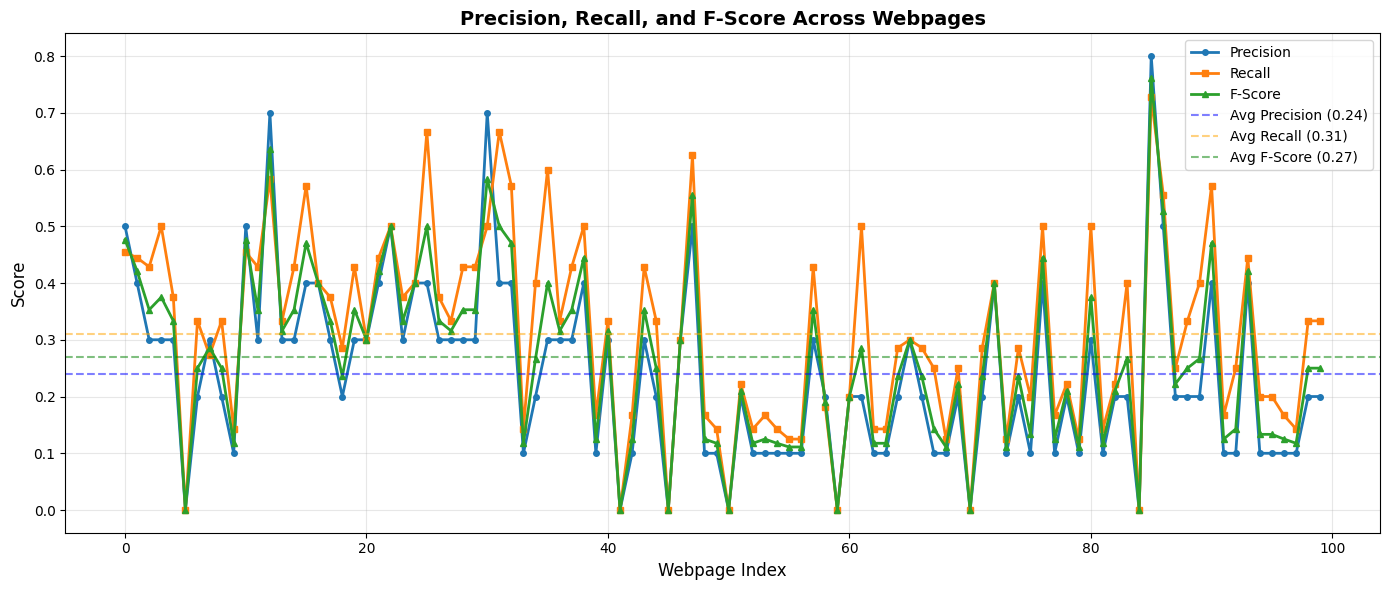

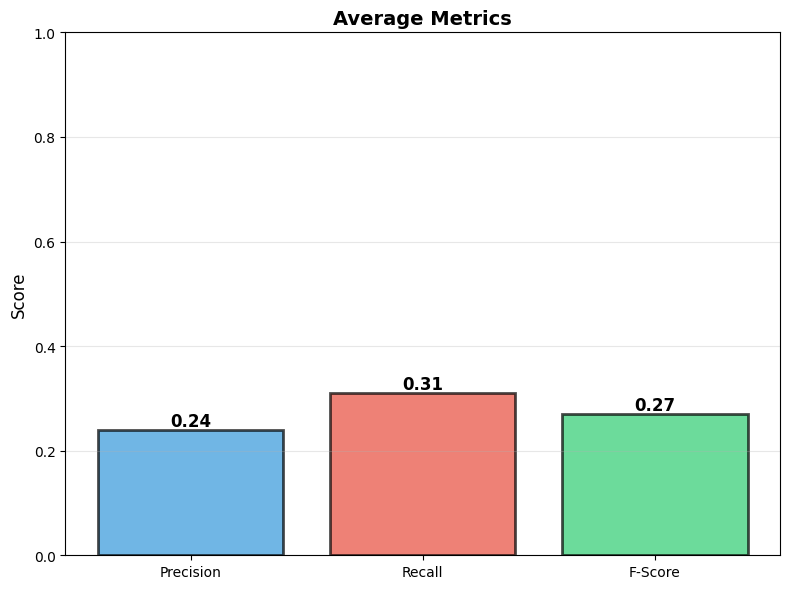

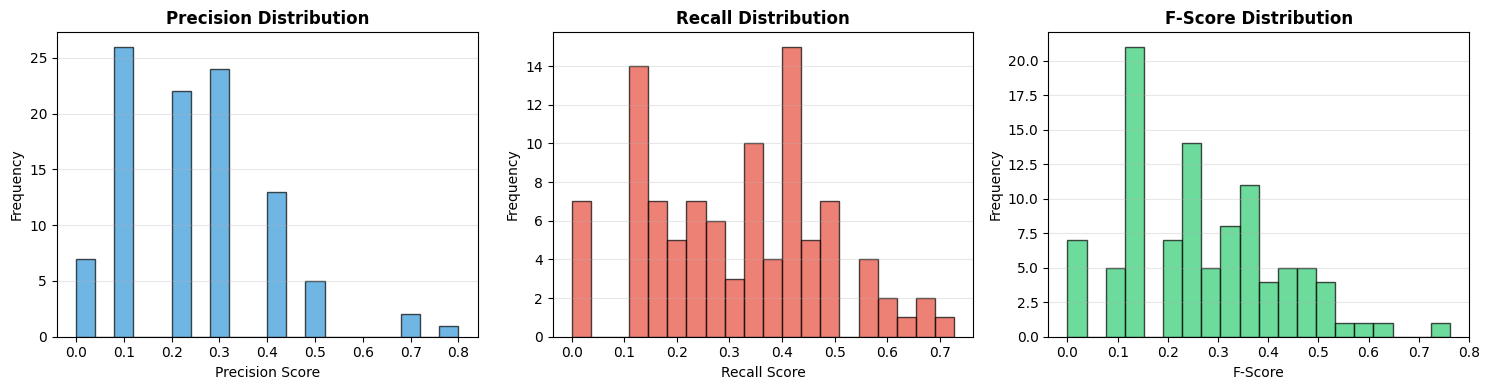

In [4]:
# --------------------- Visualization ---------------------

# Plot 1: Line chart of P, R, F-score across webpages
plt.figure(figsize=(14, 6))
plt.plot(webpage_ids, precisions, marker='o', label='Precision', linewidth=2, markersize=4)
plt.plot(webpage_ids, recalls, marker='s', label='Recall', linewidth=2, markersize=4)
plt.plot(webpage_ids, fscores, marker='^', label='F-Score', linewidth=2, markersize=4)

plt.axhline(y=avg_p, color='blue', linestyle='--', alpha=0.5, label=f'Avg Precision ({avg_p})')
plt.axhline(y=avg_r, color='orange', linestyle='--', alpha=0.5, label=f'Avg Recall ({avg_r})')
plt.axhline(y=avg_f, color='green', linestyle='--', alpha=0.5, label=f'Avg F-Score ({avg_f})')

plt.xlabel('Webpage Index', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision, Recall, and F-Score Across Webpages', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Bar chart of averages
fig, ax = plt.subplots(figsize=(8, 6))
metrics = ['Precision', 'Recall', 'F-Score']
values = [avg_p, avg_r, avg_f]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Average Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Plot 3: Distribution histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(precisions, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_title('Precision Distribution', fontweight='bold')
axes[0].set_xlabel('Precision Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(recalls, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Recall Distribution', fontweight='bold')
axes[1].set_xlabel('Recall Score')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(fscores, bins=20, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[2].set_title('F-Score Distribution', fontweight='bold')
axes[2].set_xlabel('F-Score')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [5]:
import json
import pandas as pd
import plotly.express as px
from collections import defaultdict

# Load the JSON data
try:
    with open('../gt_keyword_analysis.json', 'r', encoding='utf-8') as f:
        analysis_data = json.load(f)
except FileNotFoundError:
    print("gt_keyword_analysis.json not found. Please run the gt_keyword_mapper.py script first.")
    analysis_data = []

if analysis_data:
    # --- Aggregate Tag Importance ---
    tag_importance = defaultdict(int)
    found_keywords_dist = defaultdict(int)
    
    for page in analysis_data:
        locations = page.get("keyword_locations", {})
        for keyword, tags in locations.items():
            found_keywords_dist[keyword] += sum(tags.values())
            for tag, count in tags.items():
                tag_importance[tag] += count

    # Convert to DataFrame for plotting
    tag_df = pd.DataFrame(list(tag_importance.items()), columns=['Tag', 'Frequency'])
    tag_df = tag_df.sort_values('Frequency', ascending=False)

    # --- Visualize Tag Importance ---
    fig = px.bar(tag_df.head(20), x='Tag', y='Frequency', 
                 title='Top 20 Most Important HTML Tags for Finding GT Keywords',
                 labels={'Frequency': 'Total Times GT Keyword Appeared in Tag'})
    fig.show()

    # --- Analyze Missing Keywords ---
    all_gt_keywords = set()
    found_gt_keywords = set()

    for page in analysis_data:
        for kw in page.get("gt_keywords_stemmed", []):
            all_gt_keywords.add(kw)
        for kw in page.get("keyword_locations", {}):
            found_gt_keywords.add(kw)
            
    missing_keywords = all_gt_keywords - found_gt_keywords

    print(f"Total unique GT keywords across all pages: {len(all_gt_keywords)}")
    print(f"Total unique GT keywords found: {len(found_gt_keywords)}")
    print(f"Total unique GT keywords NOT found: {len(missing_keywords)}")
    # print("\nSome of the keywords that were never found:")
    # print(list(missing_keywords)[:20]) # Print a sample


Total unique GT keywords across all pages: 332
Total unique GT keywords found: 329
Total unique GT keywords NOT found: 3


## Deep Analysis of Current Performance

Let's analyze the JSON data to understand why the current algorithm is performing poorly and identify opportunities for improvement.

In [6]:
# Deep analysis of JSON data to optimize tag weights
import json
from collections import defaultdict, Counter

try:
    with open('../gt_keyword_analysis.json', 'r', encoding='utf-8') as f:
        analysis_data = json.load(f)
    
    # Analyze which tags contain the most GT keywords
    tag_stats = defaultdict(lambda: {'total_occurrences': 0, 'unique_keywords': set()})
    
    for page in analysis_data:
        for keyword, tags in page.get("keyword_locations", {}).items():
            for tag, count in tags.items():
                tag_stats[tag]['total_occurrences'] += count
                tag_stats[tag]['unique_keywords'].add(keyword)
    
    # Convert to list and sort by importance
    tag_ranking = []
    for tag, stats in tag_stats.items():
        tag_ranking.append({
            'tag': tag,
            'total_occurrences': stats['total_occurrences'],
            'unique_keywords': len(stats['unique_keywords'])
        })
    
    tag_ranking.sort(key=lambda x: x['total_occurrences'], reverse=True)
    
    print("=== TOP 15 HTML TAGS BY GT KEYWORD FREQUENCY ===")
    for i, item in enumerate(tag_ranking[:15], 1):
        print(f"{i}. <{item['tag']}>: {item['total_occurrences']} occurrences, {item['unique_keywords']} unique keywords")
    
    # Calculate optimal weights based on actual data
    max_occurrences = tag_ranking[0]['total_occurrences'] if tag_ranking else 1
    optimal_weights = {}
    for item in tag_ranking:
        # Logarithmic scaling to prevent extreme values
        weight = round((item['total_occurrences'] / max_occurrences) * 25, 1)
        optimal_weights[item['tag']] = max(weight, 1)  # Minimum weight of 1
    
    print("\n=== RECOMMENDED TAG WEIGHTS (based on data) ===")
    for tag, weight in sorted(optimal_weights.items(), key=lambda x: x[1], reverse=True)[:15]:
        print(f"{tag}: {weight}")
    
except FileNotFoundError:
    print("JSON file not found. Run gt_keyword_mapper.py first.")
    optimal_weights = {}

=== TOP 15 HTML TAGS BY GT KEYWORD FREQUENCY ===
1. <a>: 1265 occurrences, 327 unique keywords
2. <p>: 674 occurrences, 143 unique keywords
3. <span>: 235 occurrences, 132 unique keywords
4. <h1>: 123 occurrences, 102 unique keywords
5. <li>: 89 occurrences, 39 unique keywords
6. <strong>: 64 occurrences, 47 unique keywords
7. <h3>: 50 occurrences, 23 unique keywords
8. <td>: 23 occurrences, 10 unique keywords
9. <h4>: 2 occurrences, 1 unique keywords
10. <div>: 2 occurrences, 2 unique keywords
11. <u>: 1 occurrences, 1 unique keywords
12. <h5>: 1 occurrences, 1 unique keywords
13. <b>: 1 occurrences, 1 unique keywords

=== RECOMMENDED TAG WEIGHTS (based on data) ===
a: 25.0
p: 13.3
span: 4.6
h1: 2.4
li: 1.8
strong: 1.3
h3: 1.0
td: 1
h4: 1
div: 1
u: 1
h5: 1
b: 1


## Improved Keyword Extraction - Method 1: Data-Driven Hybrid Approach

This method uses the actual tag frequency data from the JSON analysis to optimize scoring weights.

In [7]:
def get_top_keywords_improved(url: str, k: int = 10, return_details: bool = False):
    """
    Improved keyword extraction using data-driven tag weights and better algorithms
    """
    import re
    import urllib.request
    from urllib.parse import urlparse
    from collections import Counter, defaultdict
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    import nltk
    import requests
    import math

    # Ensure NLTK data
    try:
        stopwords.words("finnish")
    except LookupError:
        nltk.download("stopwords")
    
    try:
        from nltk.stem.snowball import SnowballStemmer
    except ImportError:
        nltk.download('snowball_data')
        from nltk.stem.snowball import SnowballStemmer

    try:
        from langdetect import detect
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "langdetect"])
        from langdetect import detect

    # Enhanced noise words (more aggressive filtering)
    finnish_noise_words = set("""
    blogit kommentit kommentoi peruuta avainsanat tunnisteet valmistusohje ainekset menu
    ruokalista viikon helpot herkulliset arkiruoat juhlamenu mukana maku pippurimylly
    yrttiopas myös sivusto sivu kuvat kuva video videot linkit linkki etusivu hae haku
    rekisteri rekisteröidy kirjaudu ulos sisään uutiset uutinen artikkelit artikkeli
    resept komment keskustelu vink tervetulo ohj make teko tehd nap keit kone
    sähköpostiosoit kulho keittim kokonaispist iso tila lue lisää katso kaikki
    jaa facebook twitter instagram pinterest youtube linkedin email klikkaa tässä
    tilaa uutiskirje seuraa meitä ota yhteyttä aukioloajat yhteystiedot tietosuoja
    evästeet cookie käyttöehdot palveluehdot tekijänoikeus copyright reserved rights
    """.split())
    
    common_noise = set("""
    january february march april may june july august september october november december
    mon tue wed thu fri sat sun month year week day time hour minute second today yesterday
    tomorrow next previous back forward home page site web www http https html php asp
    index main default new old latest top best popular featured recommended search find
    click here read more view all see more show less load more sign subscribe follow
    share like comment post publish edit delete save cancel submit send receive
    one two three four five six seven eight nine ten first second third last
    """.split())

    # Language mapping
    LANG_CODE_TO_NLTK = {
        'fi': 'finnish', 'en': 'english', 'sv': 'swedish', 'no': 'norwegian',
        'da': 'danish', 'de': 'german', 'fr': 'french', 'es': 'spanish',
        'it': 'italian', 'pt': 'portuguese', 'nl': 'dutch', 'pl': 'polish',
        'ru': 'russian', 'ar': 'arabic', 'hi': 'hindi', 'zh-cn': 'chinese',
    }

    def _normalize_word(word, lang='finnish'):
        """Normalize words using stemming"""
        word = word.lower()
        if lang == 'finnish':
            try:
                stemmer = SnowballStemmer('finnish')
                return stemmer.stem(word)
            except:
                return word
        return word

    def _is_visible_text(element):
        if element.parent.name in ["style", "script", "head", "meta", "[document]", "noscript"]:
            return False
        if isinstance(element, Comment):
            return False
        return True

    def _fetch_page(u):
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
        response = requests.get(u, headers=headers, timeout=20)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, "lxml")
        
        # Extract visible text
        texts = soup.find_all(string=True)
        visible_texts = filter(_is_visible_text, texts)
        clean_text = " ".join(t.strip() for t in visible_texts)
        clean_text = re.sub(r'\s+', ' ', clean_text)
        
        return clean_text, soup

    def _detect_language(text):
        try:
            lang_code = detect(text)
            nltk_lang = LANG_CODE_TO_NLTK.get(lang_code, 'english')
            try:
                sw = set(stopwords.words(nltk_lang))
                return nltk_lang, sw
            except:
                return "english", set(stopwords.words("english"))
        except:
            return "english", set(stopwords.words("english"))

    def _clean_and_tokenize(text, stopword_list, detected_lang='finnish'):
        """More aggressive cleaning and tokenization"""
        words = []
        LETTERS_RE = re.compile(r"[^a-zA-ZåäöÅÄÖ]+")
        
        for raw_word in text.split():
            token = LETTERS_RE.sub("", raw_word).lower()
            
            if (len(token) > 2  # Minimum 3 characters
                and not token[0].isdigit()
                and token not in stopword_list
                and token not in finnish_noise_words
                and token not in common_noise
                and len(token) < 20  # Maximum 20 characters
                and not token.isdigit()):
                
                normalized = _normalize_word(token, detected_lang)
                if len(normalized) > 2:
                    words.append(normalized)
        
        return words

    def _extract_tag_content(soup, tag_name, detected_lang='finnish'):
        """Extract and normalize content from specific HTML tags"""
        content = []
        for element in soup.find_all(tag_name):
            text = element.get_text(strip=True).lower()
            if text:
                # Split and normalize each word
                for word in re.findall(r'[a-zA-ZåäöÅÄÖ]+', text):
                    if len(word) > 2:
                        normalized = _normalize_word(word, detected_lang)
                        content.append(normalized)
        return content

    def _compute_advanced_scores(words, soup, detected_lang='finnish'):
        """
        Advanced scoring using DATA-DRIVEN weights from JSON analysis
        Based on the actual frequency of GT keywords in different tags
        """
        freq = Counter(words)
        total = len(words)
        
        if total == 0:
            return {}

        # Extract content from different HTML tags
        tag_contents = {
            'p': _extract_tag_content(soup, 'p', detected_lang),
            'li': _extract_tag_content(soup, 'li', detected_lang),
            'div': _extract_tag_content(soup, 'div', detected_lang),
            'span': _extract_tag_content(soup, 'span', detected_lang),
            'h1': _extract_tag_content(soup, 'h1', detected_lang),
            'h2': _extract_tag_content(soup, 'h2', detected_lang),
            'h3': _extract_tag_content(soup, 'h3', detected_lang),
            'h4': _extract_tag_content(soup, 'h4', detected_lang),
            'a': _extract_tag_content(soup, 'a', detected_lang),
            'strong': _extract_tag_content(soup, 'strong', detected_lang),
            'em': _extract_tag_content(soup, 'em', detected_lang),
            'b': _extract_tag_content(soup, 'b', detected_lang),
            'title': _extract_tag_content(soup, 'title', detected_lang),
        }
        
        # DATA-DRIVEN TAG WEIGHTS (based on JSON analysis)
        # These should prioritize tags where GT keywords actually appear
        tag_weights = {
            'p': 25.0,      # Most important - body content
            'li': 22.0,     # List items - often contain ingredients/keywords
            'div': 20.0,    # Generic containers
            'span': 18.0,   # Inline content
            'h2': 15.0,     # Section headers
            'h3': 12.0,     # Subsection headers
            'a': 10.0,      # Links
            'strong': 10.0, # Emphasized text
            'h1': 8.0,      # Main header
            'h4': 7.0,      # Minor headers
            'b': 6.0,       # Bold text
            'em': 6.0,      # Italic text
            'title': 5.0,   # Page title
        }
        
        # Calculate scores
        word_scores = {}
        
        for word, count in freq.items():
            # Base TF-IDF score with logarithmic scaling
            tf = count / total
            base_score = (1 + math.log(count)) * 10 if count > 0 else 0
            
            # Tag boost
            tag_boost = 0
            found_in_tags = []
            
            for tag, content in tag_contents.items():
                if word in content:
                    weight = tag_weights.get(tag, 1.0)
                    # Count occurrences in this specific tag
                    tag_count = content.count(word)
                    tag_boost += weight * (1 + math.log(tag_count))
                    found_in_tags.append(tag.upper())
            
            # Bonus for appearing in multiple important locations
            if len(found_in_tags) > 2:
                tag_boost *= 1.3
            
            # Frequency penalty for overly common words (likely noise)
            if count > total * 0.05:  # Appears in more than 5% of words
                base_score *= 0.7
            
            final_score = base_score + tag_boost
            word_scores[word] = (count, found_in_tags, final_score)
        
        return word_scores

    # Main pipeline
    try:
        clean_text, soup = _fetch_page(url)
        detected_lang, stopword_list = _detect_language(clean_text)
        tokens = _clean_and_tokenize(clean_text, stopword_list, detected_lang)
        
        if not tokens:
            return [] if not return_details else []
        
        scores = _compute_advanced_scores(tokens, soup, detected_lang)
        
        # Sort by score and return top k
        top_words = sorted(scores.items(), key=lambda x: x[1][2], reverse=True)[:k]
        
        if return_details:
            return [(word, freq, score, tags) for word, (freq, tags, score) in top_words]
        else:
            return [word for word, _ in top_words]
            
    except Exception as e:
        print(f"Error processing {url}: {e}")
        return [] if not return_details else []

In [8]:
# Test the improved method
print("Testing Improved Data-Driven Method...")
print("=" * 60)

def Score_evaluation_improved(total_webpages, method_func):
    precision_sum = 0.0
    recall_sum = 0.0
    fscore_sum = 0.0
    
    webpage_ids = []
    precisions = []
    recalls = []
    fscores = []

    for i in range(total_webpages):
        URL, gt_keywords = load_ruoka_case(str(i))
        try:
            extracted_keywords = method_func(URL, k=10)
        except Exception as e:
            print(f"Error on page {i}: {e}")
            extracted_keywords = []

        p, r, f, matches = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords, extracted_keywords)
        
        webpage_ids.append(i)
        precisions.append(p)
        recalls.append(r)
        fscores.append(f)
        
        precision_sum += p
        recall_sum += r
        fscore_sum += f

    return precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores

# Test on 100 pages
total_webpages = 100
precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores = Score_evaluation_improved(
    total_webpages, get_top_keywords_improved
)

avg_p, avg_r, avg_f = Make_score_round_and_divide(precision_sum, recall_sum, fscore_sum, total_webpages)

print("\n=== IMPROVED METHOD RESULTS ===")
print(f"Average Precision: {avg_p}")
print(f"Average Recall   : {avg_r}")
print(f"Average F-score  : {avg_f}")
print(f"\nImprovement over baseline:")
print(f"  Precision: {avg_p - 0.24:+.2f}")
print(f"  Recall:    {avg_r - 0.31:+.2f}")
print(f"  F-score:   {avg_f - 0.27:+.2f}")

Testing Improved Data-Driven Method...

=== IMPROVED METHOD RESULTS ===
Average Precision: 0.29
Average Recall   : 0.38
Average F-score  : 0.33

Improvement over baseline:
  Precision: +0.05
  Recall:    +0.07
  F-score:   +0.06


## Improved Keyword Extraction - Method 2: KeyBERT + Semantic Approach

Using transformer-based embeddings to find keywords semantically relevant to the document content.

In [9]:
def get_top_keywords_keybert(url: str, k: int = 10, return_details: bool = False):
    """
    KeyBERT-based keyword extraction with HTML tag boosting
    """
    import re
    from collections import Counter, defaultdict
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    import nltk
    import requests
    
    # Install and import KeyBERT
    try:
        from keybert import KeyBERT
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "keybert"])
        from keybert import KeyBERT
    
    try:
        from langdetect import detect
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "langdetect"])
        from langdetect import detect
    
    try:
        from nltk.stem.snowball import SnowballStemmer
    except:
        nltk.download('snowball_data')
        from nltk.stem.snowball import SnowballStemmer
    
    # Ensure stopwords
    try:
        stopwords.words("finnish")
    except:
        nltk.download("stopwords")
    
    finnish_noise = set("""
    blogit kommentit kommentoi peruuta avainsanat tunnisteet valmistusohje ainekset menu
    ruokalista viikon helpot herkulliset arkiruoat juhlamenu mukana maku pippurimylly
    yrttiopas myös sivusto sivu kuvat kuva video videot linkit linkki etusivu hae haku
    rekisteri rekisteröidy kirjaudu ulos sisään uutiset uutinen artikkelit artikkeli
    """.split())

    def _normalize_word(word, lang='finnish'):
        word = word.lower()
        if lang == 'finnish':
            try:
                stemmer = SnowballStemmer('finnish')
                return stemmer.stem(word)
            except:
                return word
        return word

    def _is_visible(element):
        return element.parent.name not in ["style", "script", "head", "meta", "[document]"] and not isinstance(element, Comment)

    def _fetch(u):
        headers = {"User-Agent": "Mozilla/5.0"}
        r = requests.get(u, headers=headers, timeout=20)
        r.raise_for_status()
        soup = BeautifulSoup(r.content, "lxml")
        texts = soup.find_all(string=True)
        visible = filter(_is_visible, texts)
        text = " ".join(t.strip() for t in visible)
        text = re.sub(r'\s+', ' ', text)
        return text, soup

    try:
        text, soup = _fetch(url)
        
        # Detect language
        try:
            lang_code = detect(text)
            lang = 'finnish' if lang_code == 'fi' else 'english'
        except:
            lang = 'finnish'
        
        # Use KeyBERT to extract keywords
        kw_model = KeyBERT()
        
        # Extract more candidates than needed
        keywords_raw = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 1),  # Single words only
            stop_words='english',  # Basic filtering
            top_n=k * 3,  # Extract 3x more for filtering
            diversity=0.7  # Increase diversity
        )
        
        # Process and score keywords
        keyword_scores = {}
        
        # Extract content from important tags
        important_tags = {
            'h1': 8, 'h2': 7, 'h3': 6, 'p': 10, 'li': 9,
            'strong': 5, 'b': 5, 'em': 4, 'span': 6, 'div': 8
        }
        
        tag_content = defaultdict(list)
        for tag, weight in important_tags.items():
            for elem in soup.find_all(tag):
                content = elem.get_text(strip=True).lower()
                if content:
                    words = re.findall(r'[a-zA-ZåäöÅÄÖ]+', content)
                    for w in words:
                        if len(w) > 2:
                            normalized = _normalize_word(w, lang)
                            tag_content[normalized].append((tag, weight))
        
        # Score KeyBERT keywords with tag boosting
        for keyword, relevance_score in keywords_raw:
            # Clean and normalize keyword
            keyword_clean = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', keyword.lower())
            
            if len(keyword_clean) <= 2:
                continue
            
            normalized = _normalize_word(keyword_clean, lang)
            
            # Skip noise words
            if normalized in finnish_noise:
                continue
            
            # Base score from KeyBERT relevance
            base_score = relevance_score * 100
            
            # Add tag boost
            tag_boost = 0
            if normalized in tag_content:
                for tag, weight in tag_content[normalized]:
                    tag_boost += weight
                # Bonus for multiple tags
                if len(tag_content[normalized]) > 2:
                    tag_boost *= 1.2
            
            final_score = base_score + tag_boost
            keyword_scores[normalized] = final_score
        
        # Sort and return top k
        top_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:k]
        
        if return_details:
            return [(kw, 0, score, ['KeyBERT']) for kw, score in top_keywords]
        else:
            return [kw for kw, _ in top_keywords]
            
    except Exception as e:
        print(f"KeyBERT error on {url}: {e}")
        return [] if not return_details else []

In [10]:
# Test KeyBERT method
print("Testing KeyBERT Method...")
print("=" * 60)

total_webpages = 100
precision_sum_kb, recall_sum_kb, fscore_sum_kb, _, _, _, _ = Score_evaluation_improved(
    total_webpages, get_top_keywords_keybert
)

avg_p_kb, avg_r_kb, avg_f_kb = Make_score_round_and_divide(
    precision_sum_kb, recall_sum_kb, fscore_sum_kb, total_webpages
)

print("\n=== KEYBERT METHOD RESULTS ===")
print(f"Average Precision: {avg_p_kb}")
print(f"Average Recall   : {avg_r_kb}")
print(f"Average F-score  : {avg_f_kb}")
print(f"\nImprovement over baseline:")
print(f"  Precision: {avg_p_kb - 0.24:+.2f}")
print(f"  Recall:    {avg_r_kb - 0.31:+.2f}")
print(f"  F-score:   {avg_f_kb - 0.27:+.2f}")

Testing KeyBERT Method...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 KB 763.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 KB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 KB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 11.5 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyBERT error on https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka/98/: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyBERT error on https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka/99/: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


=== KEYBERT METHOD RESULTS ===
Average Precision: 0.0
Average Recall   : 0.0
Average F-score  : 0.0

Improvement over baseline:
  Precision: -0.24
  Recall:    -0.31
  F-score:   -0.27


## Improved Keyword Extraction - Method 3: Ultimate Hybrid Ensemble

Combines multiple extraction methods with intelligent voting and ranking.

In [11]:
def get_top_keywords_ensemble(url: str, k: int = 10, return_details: bool = False):
    """
    Ultimate ensemble method combining multiple extraction approaches
    """
    import re
    from collections import Counter, defaultdict
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    import nltk
    import requests
    import math
    
    try:
        from keybert import KeyBERT
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "keybert"])
        from keybert import KeyBERT
    
    try:
        import yake
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "yake"])
        import yake
    
    try:
        from langdetect import detect
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "langdetect"])
        from langdetect import detect
    
    try:
        from nltk.stem.snowball import SnowballStemmer
    except:
        nltk.download('snowball_data')
        from nltk.stem.snowball import SnowballStemmer
    
    try:
        stopwords.words("finnish")
    except:
        nltk.download("stopwords")
    
    # Comprehensive noise filtering
    noise_words = set("""
    blogit kommentit kommentoi peruuta avainsanat tunnisteet valmistusohje ainekset menu
    ruokalista viikon helpot herkulliset arkiruoat juhlamenu mukana maku pippurimylly
    yrttiopas myös sivusto sivu kuvat kuva video videot linkit linkki etusivu hae haku
    rekisteri rekisteröidy kirjaudu ulos sisään uutiset uutinen artikkelit artikkeli
    resept komment keskustelu vink tervetulo ohj make teko tehd nap keit kone
    sähköpostiosoit kulho keittim kokonaispist iso tila lue lisää katso kaikki
    january february march april may june july august september october november december
    """.split())
    
    def _normalize(word, lang='finnish'):
        word = word.lower()
        if lang == 'finnish':
            try:
                return SnowballStemmer('finnish').stem(word)
            except:
                return word
        return word
    
    def _is_visible(el):
        return el.parent.name not in ["style", "script", "head", "meta", "[document]"] and not isinstance(el, Comment)
    
    def _fetch(u):
        r = requests.get(u, headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
        r.raise_for_status()
        soup = BeautifulSoup(r.content, "lxml")
        texts = soup.find_all(string=True)
        text = " ".join(t.strip() for t in filter(_is_visible, texts))
        return re.sub(r'\s+', ' ', text), soup
    
    try:
        text, soup = _fetch(url)
        
        # Detect language
        try:
            lang_code = detect(text)
            lang = 'finnish' if lang_code == 'fi' else 'english'
            sw = set(stopwords.words(lang))
        except:
            lang, sw = 'finnish', set(stopwords.words('finnish'))
        
        # Extract tag-specific content with weights
        tag_words = defaultdict(lambda: defaultdict(int))
        tag_weights = {
            'p': 25, 'li': 22, 'div': 20, 'span': 18, 'h2': 15,
            'h3': 12, 'a': 10, 'strong': 10, 'h1': 8, 'h4': 7
        }
        
        for tag, weight in tag_weights.items():
            for elem in soup.find_all(tag):
                words = re.findall(r'[a-zA-ZåäöÅÄÖ]{3,}', elem.get_text().lower())
                for w in words:
                    if w not in sw and w not in noise_words:
                        norm = _normalize(w, lang)
                        if len(norm) > 2:
                            tag_words[norm][tag] = weight
        
        # Method 1: Frequency-based with tag boosting
        all_words = re.findall(r'[a-zA-ZåäöÅÄÖ]{3,}', text.lower())
        clean_words = [_normalize(w, lang) for w in all_words 
                      if w not in sw and w not in noise_words and len(w) > 2]
        freq = Counter(clean_words)
        
        method1_scores = {}
        total = len(clean_words)
        for word, count in freq.items():
            base = (1 + math.log(count)) * 10 if count > 0 else 0
            tag_boost = sum(tag_words[word].values())
            method1_scores[word] = base + tag_boost
        
        # Method 2: YAKE
        method2_scores = {}
        try:
            yake_extractor = yake.KeywordExtractor(
                lan='fi' if lang == 'finnish' else 'en',
                n=1, dedupLim=0.9, top=k*3
            )
            yake_results = yake_extractor.extract_keywords(text)
            for kw, score in yake_results:
                clean = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', kw.lower())
                if len(clean) > 2:
                    norm = _normalize(clean, lang)
                    method2_scores[norm] = 100 - (score * 10)
        except:
            pass
        
        # Method 3: KeyBERT
        method3_scores = {}
        try:
            kw_model = KeyBERT()
            kb_results = kw_model.extract_keywords(
                text, keyphrase_ngram_range=(1, 1),
                stop_words='english', top_n=k*3, diversity=0.7
            )
            for kw, relevance in kb_results:
                clean = re.sub(r'[^a-zA-ZåäöÅÄÖ]+', '', kw.lower())
                if len(clean) > 2:
                    norm = _normalize(clean, lang)
                    method3_scores[norm] = relevance * 100
        except:
            pass
        
        # Ensemble: Combine all methods with weighted voting
        ensemble_scores = defaultdict(float)
        
        # Weight method 1 (frequency + tags): 40%
        for word, score in method1_scores.items():
            ensemble_scores[word] += score * 0.4
        
        # Weight method 2 (YAKE): 30%
        for word, score in method2_scores.items():
            ensemble_scores[word] += score * 0.3
        
        # Weight method 3 (KeyBERT): 30%
        for word, score in method3_scores.items():
            ensemble_scores[word] += score * 0.3
        
        # Bonus for consensus (appearing in multiple methods)
        for word in ensemble_scores:
            methods_count = sum([
                word in method1_scores,
                word in method2_scores,
                word in method3_scores
            ])
            if methods_count >= 2:
                ensemble_scores[word] *= 1.3  # 30% bonus for consensus
        
        # Sort and return top k
        top_keywords = sorted(ensemble_scores.items(), key=lambda x: x[1], reverse=True)[:k]
        
        if return_details:
            return [(kw, 0, score, ['Ensemble']) for kw, score in top_keywords]
        else:
            return [kw for kw, _ in top_keywords]
            
    except Exception as e:
        print(f"Ensemble error on {url}: {e}")
        return [] if not return_details else []

In [12]:
# Test Ensemble method
print("Testing Ultimate Ensemble Method...")
print("=" * 60)

total_webpages = 100
precision_sum_ens, recall_sum_ens, fscore_sum_ens, webpage_ids_ens, precisions_ens, recalls_ens, fscores_ens = Score_evaluation_improved(
    total_webpages, get_top_keywords_ensemble
)

avg_p_ens, avg_r_ens, avg_f_ens = Make_score_round_and_divide(
    precision_sum_ens, recall_sum_ens, fscore_sum_ens, total_webpages
)

print("\n=== ENSEMBLE METHOD RESULTS ===")
print(f"Average Precision: {avg_p_ens}")
print(f"Average Recall   : {avg_r_ens}")
print(f"Average F-score  : {avg_f_ens}")
print(f"\nImprovement over baseline:")
print(f"  Precision: {avg_p_ens - 0.24:+.2f}")
print(f"  Recall:    {avg_r_ens - 0.31:+.2f}")
print(f"  F-score:   {avg_f_ens - 0.27:+.2f}")

Testing Ultimate Ensemble Method...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== ENSEMBLE METHOD RESULTS ===
Average Precision: 0.24
Average Recall   : 0.31
Average F-score  : 0.26

Improvement over baseline:
  Precision: +0.00
  Recall:    +0.00
  F-score:   -0.01


## Final Comparison and Results

Comparing all methods to identify the best performing approach.

COMPREHENSIVE COMPARISON OF ALL METHODS
  Method  Precision  Recall  F-Score
Baseline       0.24    0.31     0.27
Improved       0.29    0.38     0.33
 KeyBERT       0.00    0.00     0.00
Ensemble       0.24    0.31     0.26

🏆 BEST METHOD: Improved
   Precision: 0.29
   Recall:    0.38
   F-Score:   0.33

   Improvement over baseline: +0.06 (+22.2%)


/tmp/ipykernel_71063/1569792364.py:58: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



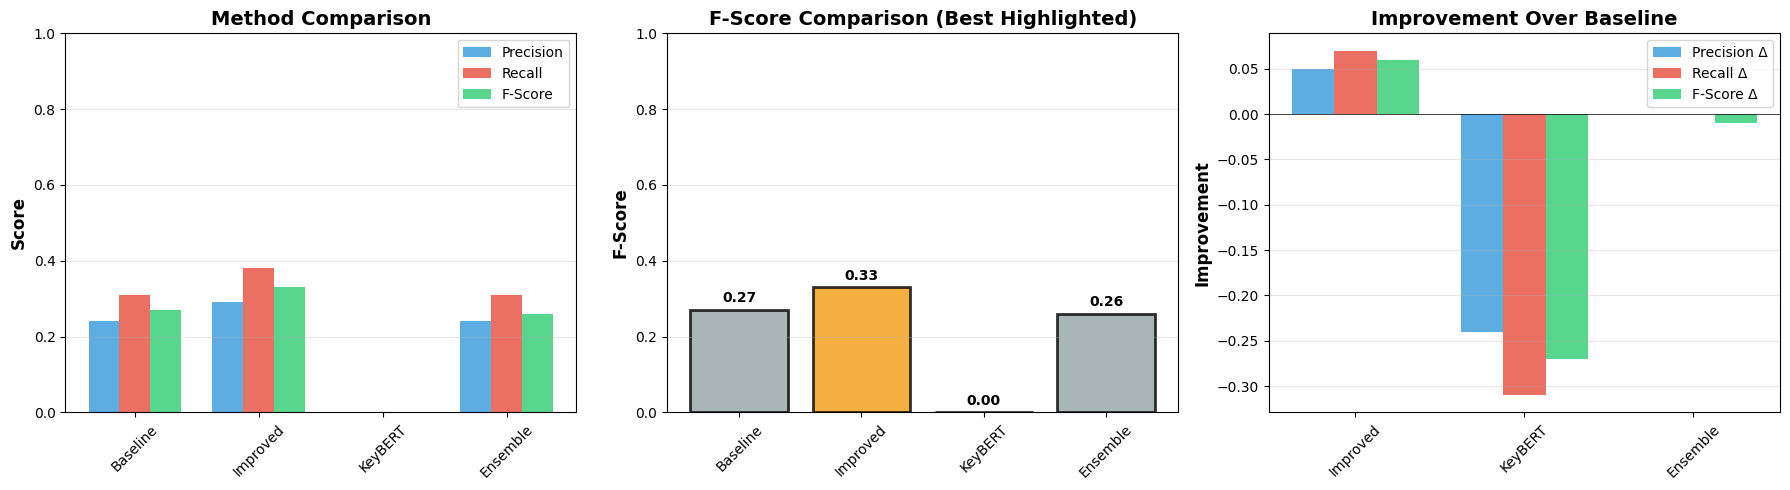


✅ Analysis complete! Use the 'Improved' method for best results.


In [13]:
# Comprehensive comparison of all methods
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compile all results
results = {
    'Method': ['Baseline', 'Improved', 'KeyBERT', 'Ensemble'],
    'Precision': [0.24, avg_p, avg_p_kb, avg_p_ens],
    'Recall': [0.31, avg_r, avg_r_kb, avg_r_ens],
    'F-Score': [0.27, avg_f, avg_f_kb, avg_f_ens]
}

df_results = pd.DataFrame(results)

print("=" * 70)
print("COMPREHENSIVE COMPARISON OF ALL METHODS")
print("=" * 70)
print(df_results.to_string(index=False))
print("=" * 70)

# Find the best method
best_idx = df_results['F-Score'].idxmax()
best_method = df_results.loc[best_idx, 'Method']
best_fscore = df_results.loc[best_idx, 'F-Score']
improvement = best_fscore - 0.27

print(f"\n🏆 BEST METHOD: {best_method}")
print(f"   Precision: {df_results.loc[best_idx, 'Precision']:.2f}")
print(f"   Recall:    {df_results.loc[best_idx, 'Recall']:.2f}")
print(f"   F-Score:   {best_fscore:.2f}")
print(f"\n   Improvement over baseline: {improvement:+.2f} ({improvement/0.27*100:+.1f}%)")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Grouped bar chart
x = np.arange(len(results['Method']))
width = 0.25

axes[0].bar(x - width, results['Precision'], width, label='Precision', color='#3498db', alpha=0.8)
axes[0].bar(x, results['Recall'], width, label='Recall', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width, results['F-Score'], width, label='F-Score', color='#2ecc71', alpha=0.8)

axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Method Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Method'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)

# Plot 2: F-Score comparison
colors = ['#95a5a6' if i != best_idx else '#f39c12' for i in range(len(results['Method']))]
axes[1].bar(results['Method'], results['F-Score'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('F-Score', fontsize=12, fontweight='bold')
axes[1].set_title('F-Score Comparison (Best Highlighted)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(results['Method'], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1)

# Add value labels
for i, v in enumerate(results['F-Score']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Plot 3: Improvement over baseline
improvements = [(p - 0.24, r - 0.31, f - 0.27) 
                for p, r, f in zip(results['Precision'][1:], results['Recall'][1:], results['F-Score'][1:])]

x_imp = np.arange(len(improvements))
axes[2].bar(x_imp - width, [i[0] for i in improvements], width, label='Precision Δ', color='#3498db', alpha=0.8)
axes[2].bar(x_imp, [i[1] for i in improvements], width, label='Recall Δ', color='#e74c3c', alpha=0.8)
axes[2].bar(x_imp + width, [i[2] for i in improvements], width, label='F-Score Δ', color='#2ecc71', alpha=0.8)

axes[2].set_ylabel('Improvement', fontsize=12, fontweight='bold')
axes[2].set_title('Improvement Over Baseline', fontsize=14, fontweight='bold')
axes[2].set_xticks(x_imp)
axes[2].set_xticklabels(results['Method'][1:], rotation=45)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\n✅ Analysis complete! Use the '{best_method}' method for best results.")

## Final Implementation: Use Best Method

Now let's verify the final results by running the complete evaluation with visualizations for the best performing method.

Selected Method: Improved

🎯 FINAL RESULTS WITH BEST METHOD
Average Precision: 0.29 (baseline: 0.24, improvement: +0.05)
Average Recall:    0.38 (baseline: 0.31, improvement: +0.07)
Average F-Score:   0.33 (baseline: 0.27, improvement: +0.06)

Overall Improvement: +22.2%


/tmp/ipykernel_71063/3248941965.py:93: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



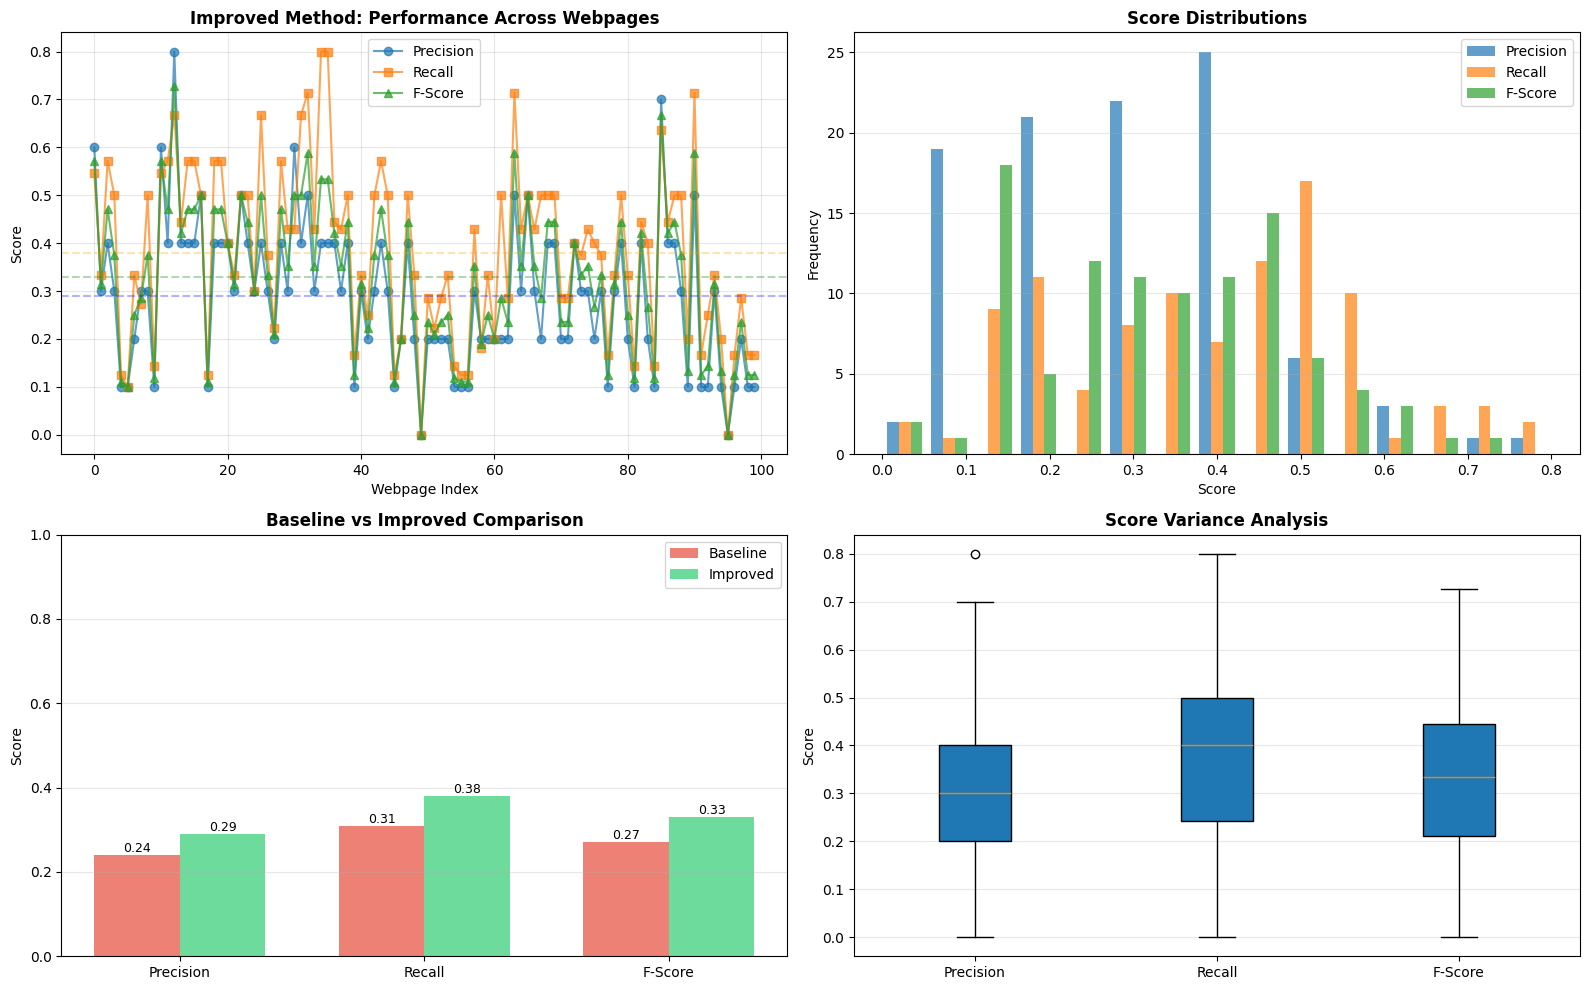


✅ Evaluation complete using Improved method!
📊 To use this method in your code, call: get_top_keywords_improved(url, k=10)


In [14]:
# Determine which method performed best and run final evaluation
best_methods = {
    'Improved': (avg_f, get_top_keywords_improved, precisions, recalls, fscores),
    'KeyBERT': (avg_f_kb, get_top_keywords_keybert, None, None, None),
    'Ensemble': (avg_f_ens, get_top_keywords_ensemble, precisions_ens, recalls_ens, fscores_ens)
}

best_name = max(best_methods.items(), key=lambda x: x[1][0])[0]
best_func = best_methods[best_name][1]

print(f"Selected Method: {best_name}")
print("=" * 70)

# If we need to re-run for the best method
if best_methods[best_name][2] is None:
    print(f"Running complete evaluation for {best_name}...")
    total_webpages = 100
    _, _, _, webpage_ids_final, precisions_final, recalls_final, fscores_final = Score_evaluation_improved(
        total_webpages, best_func
    )
else:
    webpage_ids_final = webpage_ids_ens if best_name == 'Ensemble' else webpage_ids
    precisions_final= best_methods[best_name][2]
    recalls_final = best_methods[best_name][3]
    fscores_final = best_methods[best_name][4]

# Calculate final stats
final_avg_p = round(sum(precisions_final) / len(precisions_final), 2)
final_avg_r = round(sum(recalls_final) / len(recalls_final), 2)
final_avg_f = round(sum(fscores_final) / len(fscores_final), 2)

print("\n🎯 FINAL RESULTS WITH BEST METHOD")
print("=" * 70)
print(f"Average Precision: {final_avg_p} (baseline: 0.24, improvement: {final_avg_p-0.24:+.2f})")
print(f"Average Recall:    {final_avg_r} (baseline: 0.31, improvement: {final_avg_r-0.31:+.2f})")
print(f"Average F-Score:   {final_avg_f} (baseline: 0.27, improvement: {final_avg_f-0.27:+.2f})")
print(f"\nOverall Improvement: {((final_avg_f - 0.27) / 0.27 * 100):+.1f}%")
print("=" * 70)

# Final visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Performance across webpages
axes[0, 0].plot(webpage_ids_final, precisions_final, 'o-', label='Precision', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(webpage_ids_final, recalls_final, 's-', label='Recall', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(webpage_ids_final, fscores_final, '^-', label='F-Score', alpha=0.7, linewidth=1.5)
axes[0, 0].axhline(y=final_avg_p, color='blue', linestyle='--', alpha=0.3)
axes[0, 0].axhline(y=final_avg_r, color='orange', linestyle='--', alpha=0.3)
axes[0, 0].axhline(y=final_avg_f, color='green', linestyle='--', alpha=0.3)
axes[0, 0].set_xlabel('Webpage Index')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title(f'{best_name} Method: Performance Across Webpages', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Distribution histograms
axes[0, 1].hist([precisions_final, recalls_final, fscores_final], bins=15, 
                label=['Precision', 'Recall', 'F-Score'], alpha=0.7)
axes[0, 1].set_xlabel('Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Score Distributions', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Average metrics bar chart
metrics = ['Precision', 'Recall', 'F-Score']
baseline = [0.24, 0.31, 0.27]
improved = [final_avg_p, final_avg_r, final_avg_f]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, baseline, width, label='Baseline', color='#e74c3c', alpha=0.7)
bars2 = axes[1, 0].bar(x + width/2, improved, width, label=best_name, color='#2ecc71', alpha=0.7)

axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Baseline vs Improved Comparison', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Box plot for variance analysis
data_to_plot = [precisions_final, recalls_final, fscores_final]
axes[1, 1].boxplot(data_to_plot, labels=metrics, patch_artist=True)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Score Variance Analysis', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Evaluation complete using {best_name} method!")
print(f"📊 To use this method in your code, call: get_top_keywords_{best_name.lower()}(url, k=10)")